# DFU Classification — Project Overview

**Goal**: Classify Diabetic Foot Ulcer (DFU) images into CT (Control=0) and DM (Diabetic=1)  
**Dataset**: INAOE — 334 images (CT=90, DM=244), 224×224 px, normalized [0,1], `.npy` format  
**Framework**: TensorFlow 2.21 + Keras 3  

> **Usage**: Run cells top to bottom. Training (Section 3) runs automatically — already-trained models are skipped.


In [ ]:
import sys, os, json, subprocess, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pathlib import Path
from PIL import Image

warnings.filterwarnings('ignore')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

# Always run from the project directory
PROJECT_DIR = Path('/home/ntphoto/Project')
os.chdir(PROJECT_DIR)
sys.path.insert(0, str(PROJECT_DIR))

from dfu_common import CONFIG, load_preprocessed_inaoe, create_fold_splits

CKPT_DIR    = Path(CONFIG['checkpoint_dir'])
RESULTS_DIR = Path(CONFIG['results_dir'])

def run_script(script_name):
    """Run a script via run_gpu.sh and print output."""
    proc = subprocess.run(
        ['bash', 'run_gpu.sh', script_name],
        capture_output=True, text=True, cwd=str(PROJECT_DIR),
    )
    if proc.stdout:
        print(proc.stdout)
    if proc.returncode != 0 and proc.stderr:
        print('STDERR:', proc.stderr[-3000:])
    return proc.returncode

import tensorflow as tf
print('TF version :', tf.__version__)
print('GPU        :', tf.config.list_physical_devices('GPU') or 'CPU only')
print('Data source:', CONFIG['data_source'])
print('Checkpoints:', CKPT_DIR)
print('Results    :', RESULTS_DIR)

---
## 1. Dataset & Splits

```
334 images
├── Test Set  (~67 images, 20%)  — held out
└── Train+Val (~267 images, 80%)
    ├── Fold 1  (train ~213 / val ~54)
    ├── Fold 2 … 5
```
Seed = 42, Stratified split


In [2]:
X, y = load_preprocessed_inaoe(CONFIG['data_source'])
print(f'Total images : {len(X)}')
print(f'CT  (label=0): {(y==0).sum()}')
print(f'DM  (label=1): {(y==1).sum()}')
print(f'Image shape  : {X.shape[1:]}')
print(f'Value range  : [{X.min():.3f}, {X.max():.3f}]')

Loaded INAOE: 334 images, shape=(334, 224, 224, 3), CT=90, DM=244
Total images : 334
CT  (label=0): 90
DM  (label=1): 244
Image shape  : (224, 224, 3)
Value range  : [0.000, 1.000]


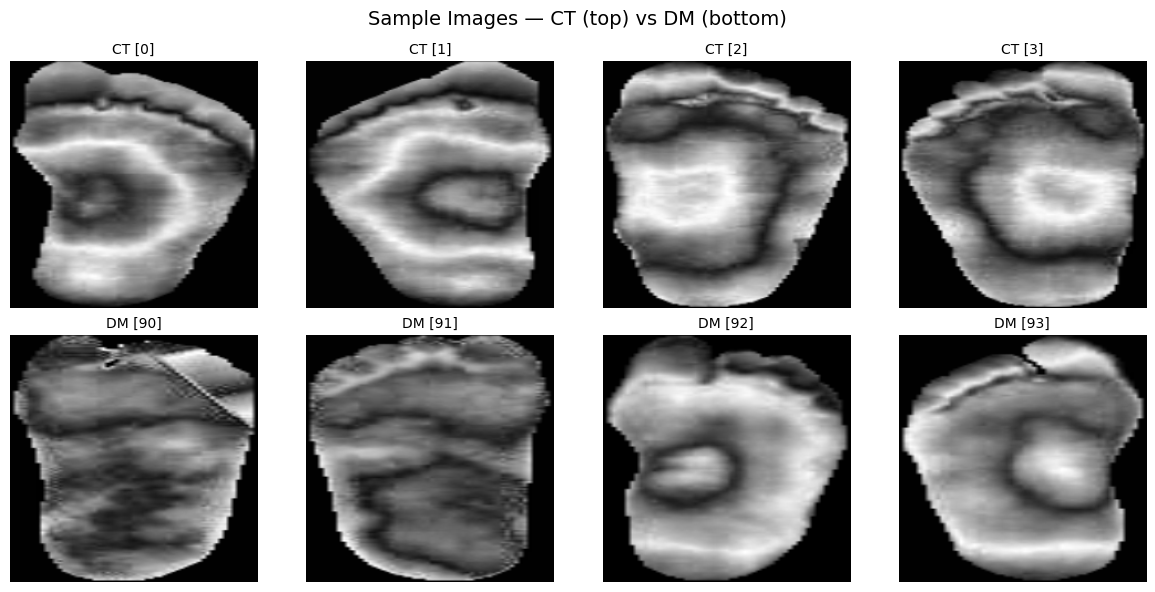

In [3]:
ct_idx = np.where(y == 0)[0][:4]
dm_idx = np.where(y == 1)[0][:4]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('Sample Images — CT (top) vs DM (bottom)', fontsize=14)
for i, idx in enumerate(ct_idx):
    axes[0, i].imshow(X[idx])
    axes[0, i].set_title(f'CT [{idx}]', fontsize=10)
    axes[0, i].axis('off')
for i, idx in enumerate(dm_idx):
    axes[1, i].imshow(X[idx])
    axes[1, i].set_title(f'DM [{idx}]', fontsize=10)
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

Train+Val : 267  (CT=72, DM=195)
Test set  : 67  (CT=18, DM=49)

  Fold 1: train=213 (CT=57, DM=156)  val=54 (CT=15, DM=39)
  Fold 2: train=213 (CT=57, DM=156)  val=54 (CT=15, DM=39)
  Fold 3: train=214 (CT=58, DM=156)  val=53 (CT=14, DM=39)
  Fold 4: train=214 (CT=58, DM=156)  val=53 (CT=14, DM=39)
  Fold 5: train=214 (CT=58, DM=156)  val=53 (CT=14, DM=39)


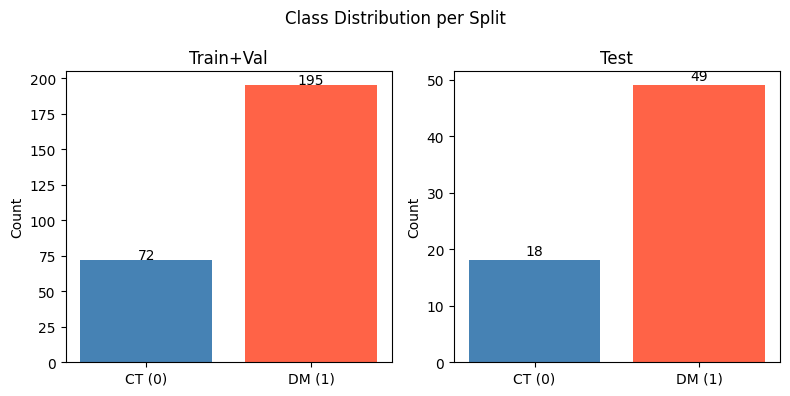

In [4]:
fold_indices, test_indices = create_fold_splits(
    X, y,
    n_splits=CONFIG['n_folds'],
    test_split=CONFIG['test_split'],
)

train_mask = np.ones(len(y), dtype=bool)
train_mask[test_indices] = False
y_trainval = y[train_mask]
y_test     = y[test_indices]

print(f'Train+Val : {len(y_trainval)}  (CT={(y_trainval==0).sum()}, DM={(y_trainval==1).sum()})')
print(f'Test set  : {len(y_test)}  (CT={(y_test==0).sum()}, DM={(y_test==1).sum()})')
print()
for fi in fold_indices:
    ytr = y[fi['train_idx']]
    yv  = y[fi['val_idx']]
    print(f"  Fold {fi['fold']+1}: train={len(ytr)} (CT={( ytr==0).sum()}, DM={(ytr==1).sum()})  "
          f"val={len(yv)} (CT={(yv==0).sum()}, DM={(yv==1).sum()})")

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
for split_i, (yl, title) in enumerate([(y_trainval, 'Train+Val'), (y_test, 'Test')]):
    counts = [(yl==0).sum(), (yl==1).sum()]
    ax[split_i].bar(['CT (0)', 'DM (1)'], counts, color=['steelblue', 'tomato'])
    ax[split_i].set_title(title)
    ax[split_i].set_ylabel('Count')
    for j, v in enumerate(counts):
        ax[split_i].text(j, v + 1, str(v), ha='center')
plt.suptitle('Class Distribution per Split')
plt.tight_layout()
plt.show()

---
## 2. Model Architecture (CNN)

```
Input (224×224×3)
    ↓
Backbone (ImageNet pretrained, frozen Phase 1)
    ↓
GlobalAveragePooling2D
    ↓
Dense(256, relu) → Dropout(0.5)
    ↓
Dense(64, relu)  → Dropout(0.5)
    ↓
Dense(1, sigmoid)
```

| Phase | Backbone | Max Epochs | Early Stop | LR |
|-------|----------|-----------|-----------|----|
| 1 | Frozen | 50 | patience=5 (val_loss) | 1e-3 |
| 2 | Unfreeze top 30% | 50 | patience=15 (val_loss) | 1e-4 (Exp decay) |


In [5]:
from dfu_common import DFUModelTrainer, base_model_creators

best_params_demo = {
    'dropout_rate': 0.5,
    'l2_reg':       1e-4,
    'dense_units_1': 256,
    'dense_units_2': 64,
}

creators  = base_model_creators()
backbones = ['EfficientNetB0', 'ResNet50', 'ConvNeXt-Tiny']

for backbone_name in backbones:
    print(f"\n{'='*60}")
    print(f"Backbone: {backbone_name}")
    print(f"{'='*60}")
    base_model = creators[backbone_name]()
    trainer = DFUModelTrainer(
        backbone_name,
        base_model,
        dropout_rate=best_params_demo['dropout_rate'],
        l2_reg=best_params_demo['l2_reg'],
        dense_units=(best_params_demo['dense_units_1'], best_params_demo['dense_units_2']),
    )
    trainer.build_model()
    trainer.model.summary(line_length=80)


Backbone: EfficientNetB0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)        │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)       │ (None, 7, 7, 1280)       │     4,049,571 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ cbam (CBAM)                       │ (None, 7, 7, 1280)       │       204,898 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d          │ (None, 1280)             │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_2 (Dense)                   │ (None, 256)              │       327,936 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_3 (Dense)                   │ (None, 64)               │        16,448 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_1 (Dropout)               │ (None, 64)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_4 (Dense)                   │ (None, 1)                │            65 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 4,598,918 (17.54 MB)

 Trainable params: 549,347 (2.10 MB)

...

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)        │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ convnext_tiny (Functional)        │ (None, 7, 7, 768)        │    27,820,128 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ cbam_2 (CBAM)                     │ (None, 7, 7, 768)        │        73,826 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d_2        │ (None, 768)              │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_12 (Dense)                  │ (None, 256)              │       196,864 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_4 (Dropout)               │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_13 (Dense)                  │ (None, 64)               │        16,448 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_5 (Dropout)               │ (None, 64)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_14 (Dense)                  │ (None, 1)                │            65 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 28,107,331 (107.22 MB)

 Trainable params: 287,203 (1.10 MB)

 Non-trainable params: 27,820,128 (106.13 MB)

---
## 3. Training

Each backbone is trained with **Optuna** hyperparameter search (10 trials on Fold 1) followed by **5-fold CV**.  
Outputs saved to `model_checkpoints/`: `best_params.json`, `val_preds.npz`, `avg_epochs.json`

- **Resume-aware**: existing checkpoints are loaded automatically — only missing folds are retrained.
- Delete files in `model_checkpoints/` to force a full retrain.


In [6]:
MODELS = ['EfficientNetB0', 'ResNet50', 'ConvNeXt-Tiny']
ARTIFACTS = ['val_preds.npz', 'best_params.json', 'avg_epochs.json']

print(f"{'Model':<18} {'val_preds':>12} {'best_params':>12} {'avg_epochs':>12}")
print('-' * 58)
for m in MODELS:
    row = ['✓' if (CKPT_DIR / f'{m}_{art}').exists() else '✗' for art in ARTIFACTS]
    print(f"{m:<18} {row[0]:>12} {row[1]:>12} {row[2]:>12}")

Model                 val_preds  best_params   avg_epochs
----------------------------------------------------------
EfficientNetB0                ✓            ✓            ✓
ResNet50                      ✓            ✓            ✓
ConvNeXt-Tiny                 ✓            ✓            ✓


In [7]:
BACKBONE_SCRIPTS = {
    'EfficientNetB0': 'train_efficientnet.py',
    'ResNet50':       'train_resnet.py',
    'ConvNeXt-Tiny':  'train_convnext.py',
}

for model_name, script in BACKBONE_SCRIPTS.items():
    all_done = all(
        (CKPT_DIR / f'{model_name}_{art}').exists()
        for art in ['val_preds.npz', 'best_params.json', 'avg_epochs.json']
    )
    if all_done:
        print(f'✓ {model_name} — already trained, skipping.')
        continue

    print(f'\n{"="*60}')
    print(f'Training {model_name} ...')
    print(f'{"="*60}')

    proc = subprocess.Popen(
        ['bash', 'run_gpu.sh', script],
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
        text=True, bufsize=1, cwd=str(PROJECT_DIR),
    )
    for line in proc.stdout:
        print(line, end='', flush=True)
    proc.wait()

    if proc.returncode == 0:
        print(f'\n✓ {model_name} training complete.')
    else:
        print(f'\n✗ {model_name} failed (exit code {proc.returncode})')
        break

✓ EfficientNetB0 — already trained, skipping.
✓ ResNet50 — already trained, skipping.
✓ ConvNeXt-Tiny — already trained, skipping.


---
## 4. RQ1 — Backbone Comparison

**Objective**: Select the best backbone from 3 candidates using 5-fold CV on the training set.

**Clinical screening criteria** (all three must be met):
- AUC-ROC ≥ 0.80
- Sensitivity ≥ 0.85
- Specificity ≥ 0.70

Results saved to: `results/rq1_results.json`


In [8]:
rq1_json = RESULTS_DIR / 'rq1_results.json'
if rq1_json.exists():
    print('rq1_results.json already exists — skipping re-run.')
    print('Delete the file if you want to re-run.')
else:
    print('Running rq1_backbone_comparison.py ...')
    rc = run_script('rq1_backbone_comparison.py')
    print('✓ Done.' if rc == 0 else f'✗ Failed (exit code {rc})')

rq1_results.json already exists — skipping re-run.
Delete the file if you want to re-run.


Best backbone: ConvNeXt-Tiny



,Backbone,AUC,Sensitivity,Specificity,Qualifies
0,EfficientNetB0,0.4298,1.0000,0.00,False
1,ResNet50,0.7483,1.0000,0.00,False
2,ConvNeXt-Tiny,0.8277,0.8205,0.68,False


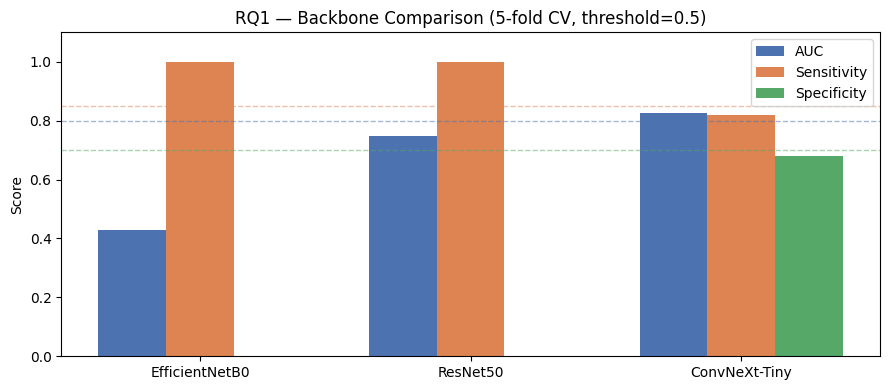

Winner: ConvNeXt-Tiny (AUC=0.8277)


In [9]:
if not rq1_json.exists():
    print(f'rq1_results.json not found. Run cell above first.')
else:
    with open(rq1_json) as f:
        rq1 = json.load(f)

    rows = []
    for entry in rq1['comparison']:
        rows.append({
            'Backbone':    entry['name'],
            'AUC':         round(entry['auc'],  4),
            'Sensitivity': round(entry['sens'], 4),
            'Specificity': round(entry['spec'], 4),
            'Qualifies':   entry['qualifies'],
        })
    df_rq1 = pd.DataFrame(rows)

    print(f"Best backbone: {rq1['best_model']}")
    print()
    display(df_rq1)

    fig, ax = plt.subplots(figsize=(9, 4))
    x = np.arange(len(df_rq1))
    w = 0.25
    colors = ['#4C72B0', '#DD8452', '#55A868']
    for i, (m, c) in enumerate(zip(['AUC', 'Sensitivity', 'Specificity'], colors)):
        ax.bar(x + i*w, df_rq1[m], w, label=m, color=c)
    for thr, c in zip([0.80, 0.85, 0.70], colors):
        ax.axhline(thr, color=c, linestyle='--', alpha=0.5, linewidth=1)
    ax.set_xticks(x + w)
    ax.set_xticklabels(df_rq1['Backbone'])
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    ax.set_title('RQ1 — Backbone Comparison (5-fold CV, threshold=0.5)')
    ax.legend()
    plt.tight_layout()
    plt.show()
    best_auc = df_rq1.loc[df_rq1['Backbone'] == rq1['best_model'], 'AUC'].values[0]
    print(f"Winner: {rq1['best_model']} (AUC={best_auc:.4f})")

---
## 5. RQ2 — Threshold Optimization (Youden's Index)

$$J = \text{Sensitivity} + \text{Specificity} - 1 \quad \Rightarrow \quad \text{thr}^* = \arg\max(\text{TPR} - \text{FPR})$$

**Step 1**: Compute per-fold Youden threshold → take the mean across folds  
**Step 2**: Apply the mean threshold to each fold's validation set and compare against default 0.5

Results saved to: `results/rq2_results.json`


In [10]:
rq2_json = RESULTS_DIR / 'rq2_results.json'
if rq2_json.exists():
    print('rq2_results.json already exists — skipping re-run.')
else:
    print('Running rq2_threshold_optimization.py ...')
    rc = run_script('rq2_threshold_optimization.py')
    print('✓ Done.' if rc == 0 else f'✗ Failed (exit code {rc})')

rq2_results.json already exists — skipping re-run.


Best model        : ConvNeXt-Tiny
Mean Youden thr   : 0.7578 ± 0.0715

Per-fold Youden thresholds:


,fold,youden_threshold,youden_sens,youden_spec
0,1,0.875895,0.692308,0.866667
1,2,0.693160,0.820513,0.800000
2,3,0.700128,0.743590,0.785714
3,4,0.805289,0.769231,0.928571
4,5,0.714556,0.871795,0.857143



Comparison: Default 0.5 vs Youden threshold


,Threshold,Sensitivity,Specificity
0,Default 0.5,0.8205 ± 0.0429,0.6800 ± 0.0373
1,Youden 0.7578,0.7641 ± 0.0470,0.8210 ± 0.0667



Δ Sensitivity : -0.0564 pp  (-6.9%)
Δ Specificity : +0.1410 pp  (+20.7%)


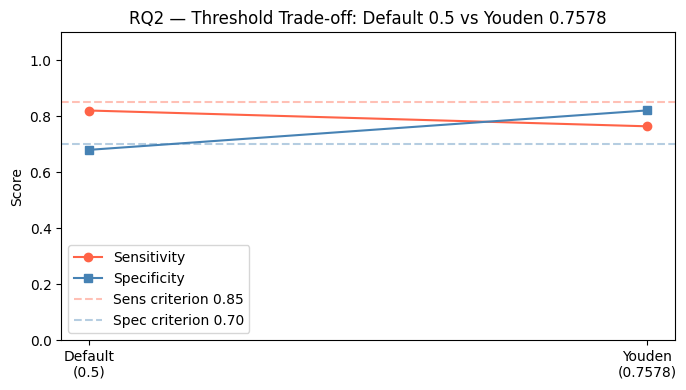

In [11]:
if not rq2_json.exists():
    print('rq2_results.json not found. Run cell above first.')
else:
    with open(rq2_json) as f:
        rq2 = json.load(f)

    mean_thr = rq2['mean_youden_threshold']
    d = rq2['default_threshold']
    y_ = rq2['youden_threshold']

    print(f"Best model        : {rq2['best_model']}")
    print(f"Mean Youden thr   : {mean_thr:.4f} ± {rq2['std_youden_threshold']:.4f}")
    print()
    print('Per-fold Youden thresholds:')
    display(pd.DataFrame(rq2['per_fold_thresholds']))

    print()
    print('Comparison: Default 0.5 vs Youden threshold')
    df_comp = pd.DataFrame([
        {'Threshold': 'Default 0.5',
         'Sensitivity': f"{d['mean_sens']:.4f} ± {d['std_sens']:.4f}",
         'Specificity': f"{d['mean_spec']:.4f} ± {d['std_spec']:.4f}"},
        {'Threshold': f"Youden {mean_thr:.4f}",
         'Sensitivity': f"{y_['mean_sens']:.4f} ± {y_['std_sens']:.4f}",
         'Specificity': f"{y_['mean_spec']:.4f} ± {y_['std_spec']:.4f}"},
    ])
    display(df_comp)

    delta_sens_pct = (rq2['delta_sens_pp'] / d['mean_sens'] * 100) if d['mean_sens'] > 1e-9 else 0
    delta_spec_pct = (rq2['delta_spec_pp'] / d['mean_spec'] * 100) if d['mean_spec'] > 1e-9 else 0
    print(f"\nΔ Sensitivity : {rq2['delta_sens_pp']:+.4f} pp  ({delta_sens_pct:+.1f}%)")
    print(f"Δ Specificity : {rq2['delta_spec_pp']:+.4f} pp  ({delta_spec_pct:+.1f}%)")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot([0.5, mean_thr], [d['mean_sens'], y_['mean_sens']], 'o-', label='Sensitivity', color='tomato')
    ax.plot([0.5, mean_thr], [d['mean_spec'], y_['mean_spec']], 's-', label='Specificity', color='steelblue')
    ax.axhline(0.85, color='tomato',    linestyle='--', alpha=0.4, label='Sens criterion 0.85')
    ax.axhline(0.70, color='steelblue', linestyle='--', alpha=0.4, label='Spec criterion 0.70')
    ax.set_xticks([0.5, mean_thr])
    ax.set_xticklabels([f'Default\n(0.5)', f"Youden\n({mean_thr:.4f})"])
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    ax.set_title(f'RQ2 — Threshold Trade-off: Default 0.5 vs Youden {mean_thr:.4f}')
    ax.legend()
    plt.tight_layout()
    plt.show()

---
## 6. RQ3 — Final Evaluation on Test Set

**Strategy**:
1. Load the average stopping epoch from 5-fold CV (`{model}_avg_epochs.json`)
2. Retrain on the **full training set** for exactly that many epochs — no early stopping
3. Evaluate on the held-out test set using the mean Youden threshold from RQ2

Results saved to: `results/rq3_results.json`, `results/rq3_test_probs.npy`


In [12]:
rq3_json = RESULTS_DIR / 'rq3_results.json'
if rq3_json.exists():
    print('rq3_results.json already exists — skipping re-run.')
else:
    print('Running rq3_final_evaluation.py (retraining on full train set) ...')
    rc = run_script('rq3_final_evaluation.py')
    print('✓ Done.' if rc == 0 else f'✗ Failed (exit code {rc})')

rq3_results.json already exists — skipping re-run.


In [ ]:
if not rq3_json.exists():
    print('rq3_results.json not found. Run cell above first.')
else:
    with open(rq3_json) as f:
        rq3 = json.load(f)

    m = rq3['test_metrics']
    print(f"Model      : {rq3['best_model']}")
    print(f"Threshold  : {rq3['threshold']:.4f}  (Youden from RQ2)")
    print(f"Epochs     : phase1={rq3['retrain_epochs']['phase1']}, phase2={rq3['retrain_epochs']['phase2']}")
    print()

    metric_labels = {
        'sensitivity': 'Sensitivity',
        'specificity': 'Specificity',
        'auc_roc':     'AUC-ROC',
        'ppv':         'PPV',
        'npv':         'NPV',
        'f1':          'F1-Score',
    }
    df_rq3 = pd.DataFrame([
        {'Metric': metric_labels[k], 'Value': round(v, 4)}
        for k, v in m.items() if k in metric_labels
    ])
    display(df_rq3)

    metrics_plot = list(metric_labels.values())
    values_plot  = [m[k] for k in metric_labels]

    fig, ax = plt.subplots(figsize=(9, 4))
    colors = ['tomato' if v < 0.70 else 'steelblue' for v in values_plot]
    bars = ax.bar(metrics_plot, values_plot, color=colors)
    ax.axhline(0.70, color='gray', linestyle='--', alpha=0.5, label='0.70 reference')
    for bar, v in zip(bars, values_plot):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.4f}', ha='center', fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.set_title(f"RQ3 — Test Set ({rq3['best_model']}, thr={rq3['threshold']:.4f})")
    ax.legend()
    plt.tight_layout()
    plt.show()


---
## 7. RQ4 — Explainability (Grad-CAM / Grad-CAM++ / Eigen-CAM)

| Method | Concept |
|--------|---------|
| **Grad-CAM** | Weight feature maps by global-avg-pooled gradients |
| **Grad-CAM++** | Alpha weights derived from 2nd-order gradients |
| **Eigen-CAM** | Gradient-free — PC1 from SVD of the feature map |

Output: 4-panel images saved to `results/rq4_gradcam/`

> **Note**: Pointing Game evaluation is deferred — the INAOE dataset does not include ground-truth ROI annotations.


In [14]:
rq4_dir = RESULTS_DIR / 'rq4_gradcam'

if rq4_dir.exists() and list(rq4_dir.glob('*.png')):
    print(f'rq4_gradcam/ already has {len(list(rq4_dir.glob("*.png")))} images — skipping re-run.')
else:
    print('Running rq4_gradcam.py ...')
    rc = run_script('rq4_gradcam.py')
    print('✓ Done.' if rc == 0 else f'✗ Failed (exit code {rc})')

rq4_gradcam/ already has 8 images — skipping re-run.


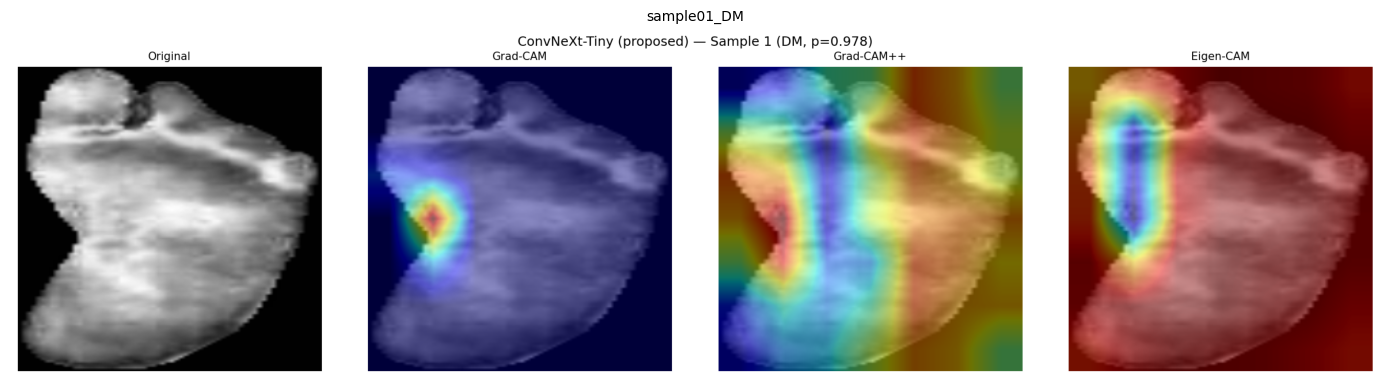

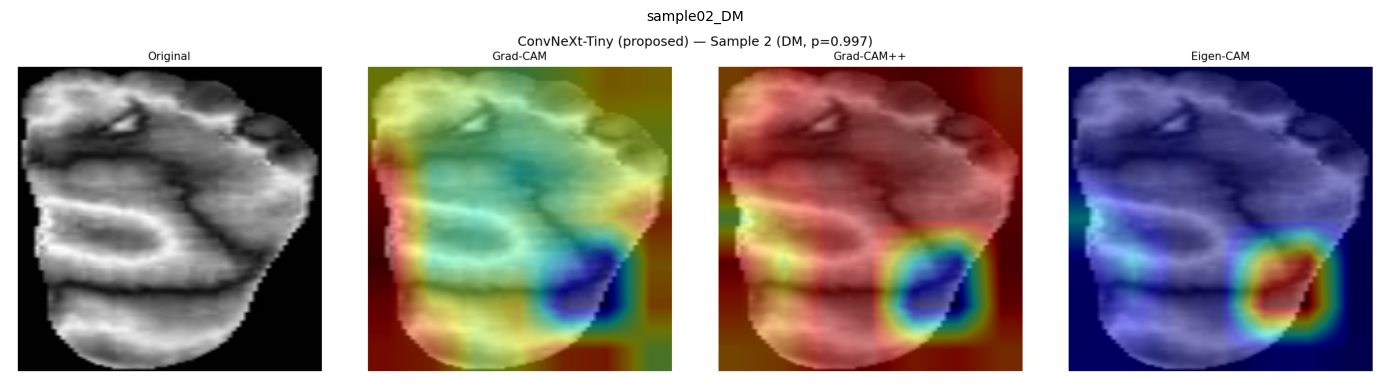

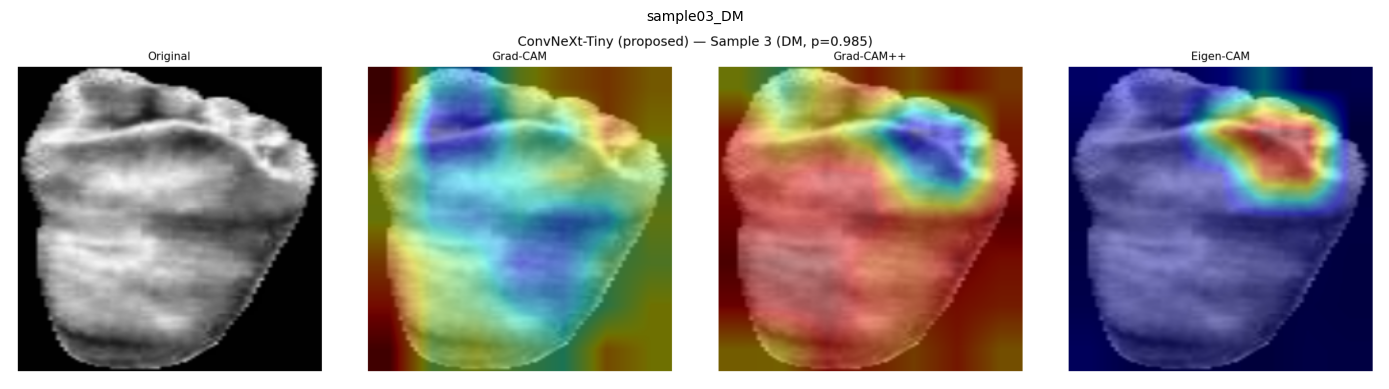

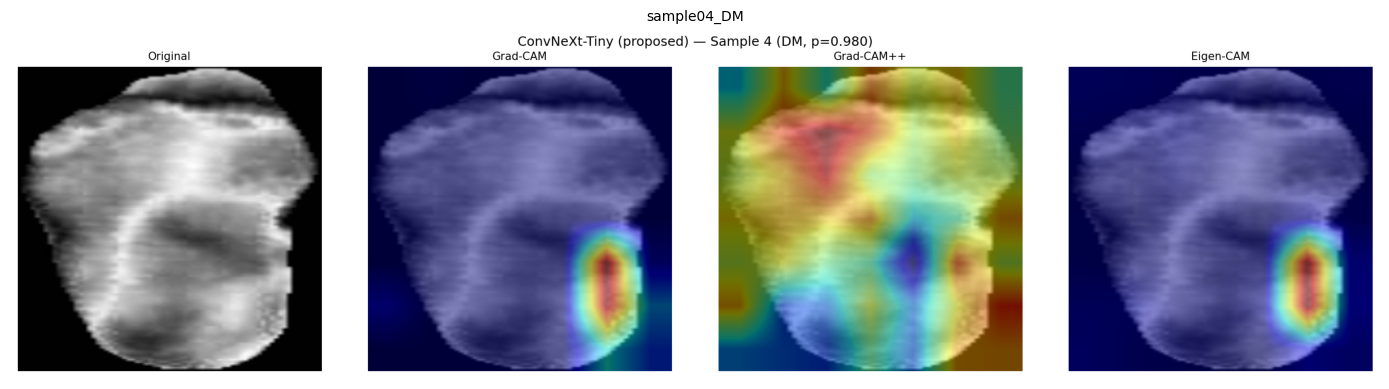

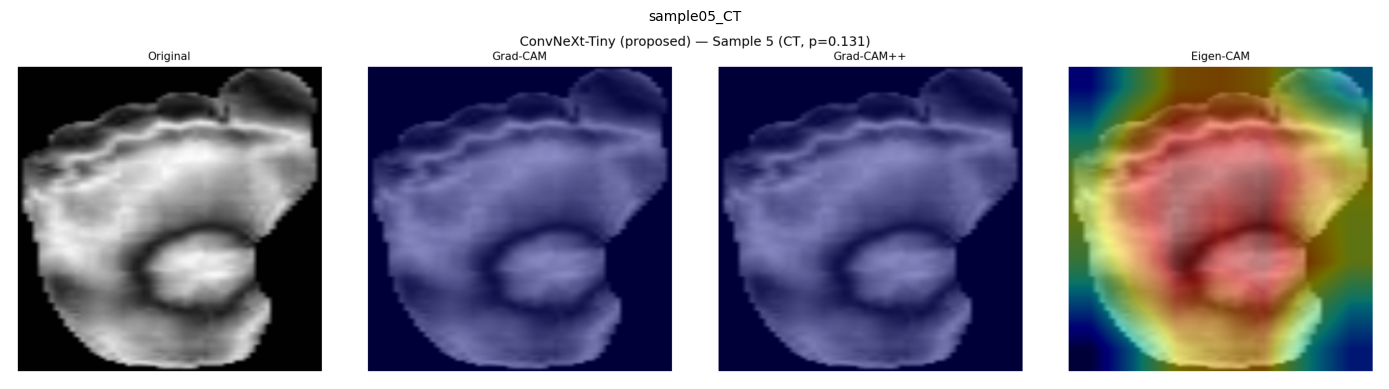

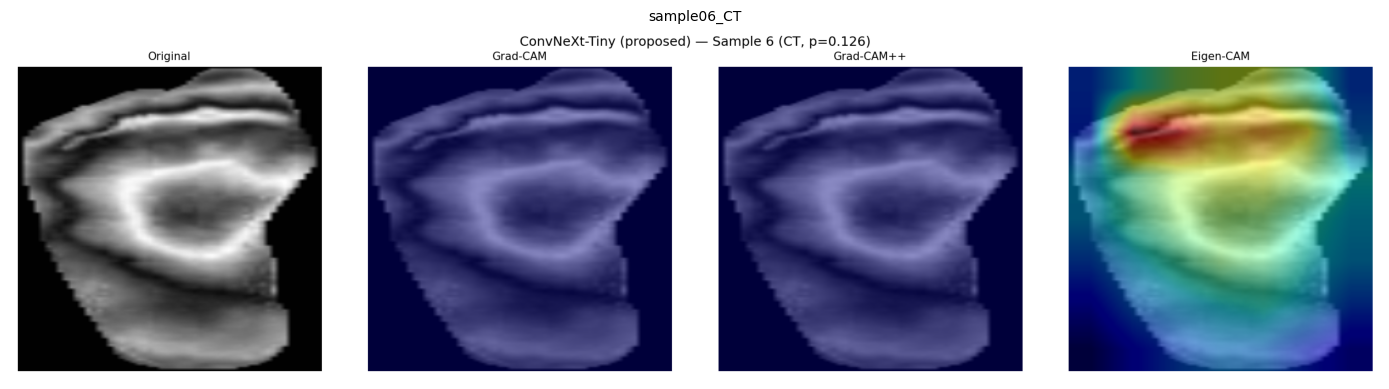

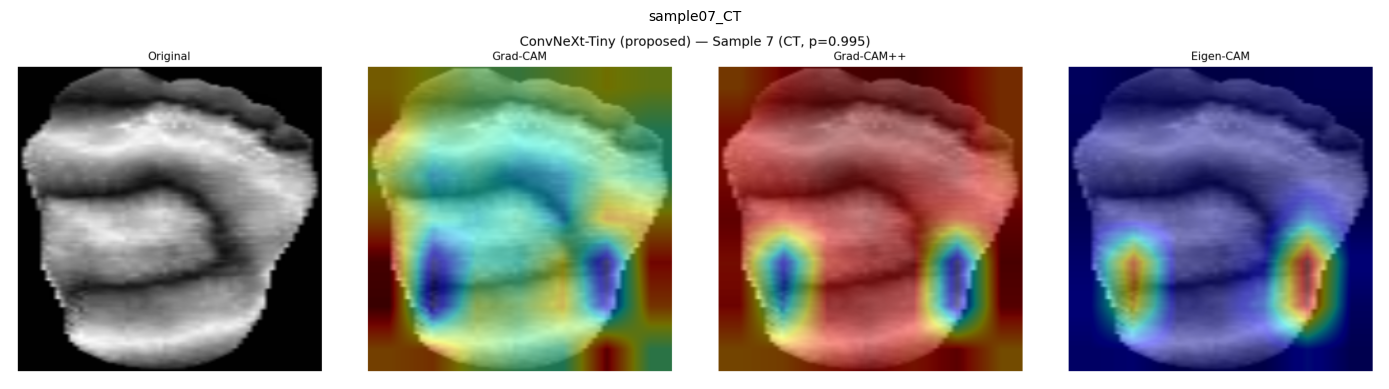

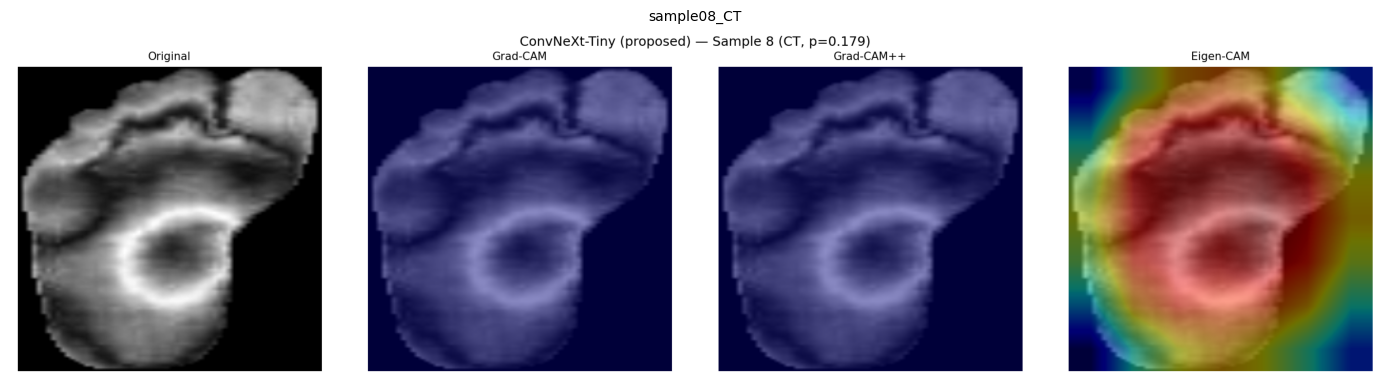

In [15]:
cam_images = sorted((RESULTS_DIR / 'rq4_gradcam').glob('*.png'))

if cam_images:
    for img_path in cam_images:
        fig, ax = plt.subplots(figsize=(14, 4))
        ax.imshow(Image.open(img_path))
        ax.set_title(img_path.stem, fontsize=10)
        ax.axis('off')
        plt.tight_layout()
        plt.show()
else:
    print('No Grad-CAM images found.')

---
## 8. RQ5 — CNN vs BPNN (GLCM + HOG)

**BPNN Feature Extraction (24-dim)**:

| Features | Details | Dim |
|----------|---------|-----|
| GLCM | 8-level quantized, 4 angles (0/45/90/135°), 4 properties × 4 angles | 16 |
| HOG | 8×8 cells, 8 statistics (mean, std, var, median, max, min, skew, kurt) | 8 |
| **Total** | | **24** |

**Statistical tests**: McNemar's Test + Bootstrap AUC p-value (2,000 samples)

Results saved to: `results/rq5_results.json`


In [25]:
rq5_json = RESULTS_DIR / 'rq5_results.json'
if rq5_json.exists():
    print('rq5_results.json already exists — skipping re-run.')
else:
    print('Running rq5_bpnn_comparison.py ...')
    rc = run_script('rq5_bpnn_comparison.py')
    print('✓ Done.' if rc == 0 else f'✗ Failed (exit code {rc})')

rq5_results.json already exists — skipping re-run.


In [ ]:
if not rq5_json.exists():
    print('rq5_results.json not found. Run cell above first.')
elif not rq3_json.exists():
    print('rq3_results.json not found. Run RQ3 section first.')
else:
    with open(rq5_json) as f:
        rq5 = json.load(f)
    with open(rq3_json) as f:
        rq3_data = json.load(f)

    bpnn_m   = rq5['test_metrics']
    cnn_m    = rq3_data['test_metrics']
    cnn_name = rq3_data['best_model']

    print(f"BPNN architecture : {rq5['bpnn_architecture']}")
    print(f"Features          : {rq5['features']}")
    print(f"Avg stopping iter : {rq5['avg_stopping_iter']}  (per fold: {rq5['fold_stopping_iters']})")
    print(f"Youden threshold  : {rq5['mean_youden_threshold']:.4f}")
    print()

    # Comparison table
    order = ['sensitivity', 'specificity', 'auc_roc', 'ppv', 'npv', 'f1']
    labels_map = {'sensitivity': 'Sensitivity', 'specificity': 'Specificity',
                  'auc_roc': 'AUC-ROC', 'ppv': 'PPV', 'npv': 'NPV', 'f1': 'F1-Score'}
    df_rq5 = pd.DataFrame([
        {
            'Metric': labels_map[k],
            f'{cnn_name}': round(cnn_m[k], 4),
            'BPNN (GLCM+HOG)':  round(bpnn_m[k], 4),
            'Δ': round(bpnn_m[k] - cnn_m[k], 4),
        }
        for k in order
    ])
    display(df_rq5)

    # Bar chart
    metrics_l = [labels_map[k] for k in order]
    cnn_vals  = [cnn_m[k]  for k in order]
    bpnn_vals = [bpnn_m[k] for k in order]
    x, w = np.arange(len(metrics_l)), 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - w/2, cnn_vals,  w, label=f'{cnn_name} (CNN)', color='steelblue')
    ax.bar(x + w/2, bpnn_vals, w, label='BPNN (GLCM+HOG)',   color='tomato')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_l)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.set_title('RQ5 — CNN vs BPNN Performance on Test Set')
    ax.legend()
    for i, (cv, bv) in enumerate(zip(cnn_vals, bpnn_vals)):
        ax.text(i - w/2, cv + 0.01, f'{cv:.3f}', ha='center', fontsize=8)
        ax.text(i + w/2, bv + 0.01, f'{bv:.3f}', ha='center', fontsize=8)
    plt.tight_layout()
    plt.show()

    # Statistical tests
    st = rq5.get('statistical_tests', {})
    if st:
        cnn_thr = rq3_data['threshold']
        print(f"\nStatistical Tests  (CNN thr={cnn_thr:.4f}, BPNN thr={rq5['mean_youden_threshold']:.4f})")
        print('─' * 60)
        mc  = st['mcnemar']
        auc = st['bootstrap_auc']
        print(f"McNemar's test   H0: both classifiers make same errors")
        print(f"  b={mc['b']} (CNN✓/BPNN✗)  c={mc['c']} (CNN✗/BPNN✓)  "
              f"p={mc['p_value']:.4f} {mc['significance']}")
        print(f"  b: {mc['b']} sample(s) CNN got right but BPNN got wrong")
        print(f"  c: {mc['c']} sample(s) BPNN got right but CNN got wrong")
        if mc['b'] == mc['c']:
            print(f"  → b == c: both classifiers made unique errors on the same {mc['b']} samples")
            print(f"    Symmetric disagreement in both directions → cannot reject H0 (p={mc['p_value']:.4f})")
        elif mc['b'] > mc['c']:
            print(f"  → CNN corrected more of BPNN's errors than vice versa (b > c)")
        else:
            print(f"  → BPNN corrected more of CNN's errors than vice versa (c > b)")
        print(f"Bootstrap AUC    H0: AUC_CNN = AUC_BPNN  (n={auc['n_bootstrap']})")
        print(f"  ΔAUC={auc['delta_auc']:+.4f}  p={auc['p_value']:.4f} {auc['significance']}")
        if auc['p_value'] >= 0.05:
            print(f"  → No significant AUC difference between models → cannot reject H0")
        else:
            print(f"  → Significant AUC difference detected → reject H0")
        print(f"\nSignificance: * p<0.05  ** p<0.01  *** p<0.001  ns = not significant")
    else:
        print("\nStatistical tests not available — re-run rq5_bpnn_comparison.py.")


---
## 9. RQ6 — BPNN Feature Interpretability (Supplementary)

| Method | Concept | Output |
|--------|---------|--------|
| **Permutation Importance** | Shuffle each feature, measure AUC drop | bar chart |
| **SHAP KernelExplainer** | Shapley value per feature per sample | beeswarm + bar |

Output: `results/rq6_bpnn_interpretability/`


In [23]:
rq6_dir  = RESULTS_DIR / 'rq6_bpnn_interpretability'
rq6_done = rq6_dir.exists() and len(list(rq6_dir.glob('*.png'))) >= 3

if rq6_done:
    print(f'rq6_bpnn_interpretability/ already has {len(list(rq6_dir.glob("*.png")))} plots — skipping re-run.')
else:
    print('Running rq6_bpnn_interpretability.py ...')
    rc = run_script('rq6_bpnn_interpretability.py')
    print('✓ Done.' if rc == 0 else f'✗ Failed (exit code {rc})')

rq6_bpnn_interpretability/ already has 3 plots — skipping re-run.


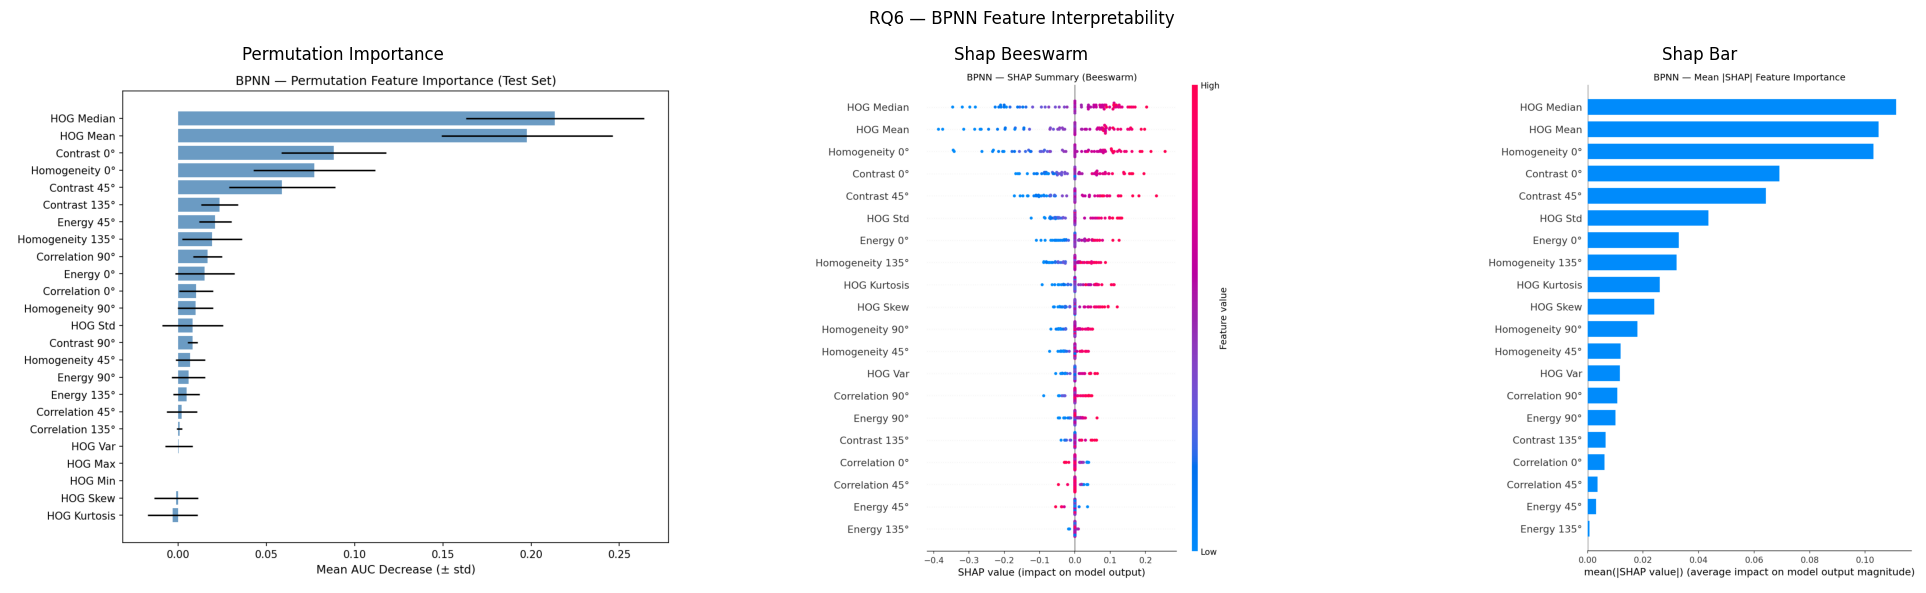

In [24]:
plots = ['permutation_importance.png', 'shap_beeswarm.png', 'shap_bar.png']
found = [rq6_dir / p for p in plots if (rq6_dir / p).exists()]

if found:
    fig, axes = plt.subplots(1, len(found), figsize=(7*len(found), 6))
    if len(found) == 1:
        axes = [axes]
    for ax, img_path in zip(axes, found):
        ax.imshow(Image.open(img_path))
        ax.set_title(img_path.stem.replace('_', ' ').title())
        ax.axis('off')
    plt.suptitle('RQ6 — BPNN Feature Interpretability')
    plt.tight_layout()
    plt.show()
else:
    print('RQ6 plots not found. Run rq6_bpnn_interpretability.py first.')

---
## 10. Summary Dashboard


In [ ]:
required = [
    RESULTS_DIR / 'rq1_results.json',
    RESULTS_DIR / 'rq2_results.json',
    RESULTS_DIR / 'rq3_results.json',
    RESULTS_DIR / 'rq5_results.json',
]
missing = [str(p) for p in required if not p.exists()]
if missing:
    print('Missing result files — run RQ sections first:')
    for p in missing:
        print(f'  {p}')
else:
    with open(RESULTS_DIR / 'rq1_results.json') as f: rq1 = json.load(f)
    with open(RESULTS_DIR / 'rq2_results.json') as f: rq2 = json.load(f)
    with open(RESULTS_DIR / 'rq3_results.json') as f: rq3 = json.load(f)
    with open(RESULTS_DIR / 'rq5_results.json') as f: rq5 = json.load(f)

    best_name  = rq1['best_model']
    best_entry = next(e for e in rq1['comparison'] if e['name'] == best_name)
    rq3m = rq3['test_metrics']
    rq5m = rq5['test_metrics']
    rq2y = rq2['youden_threshold']

    panels = [
        ('RQ1: Best Backbone\n(CV, thr=0.5)',
         best_entry['auc'], best_entry['sens'], best_entry['spec']),
        ('RQ2: Youden Threshold\n(CV)',
         0.0, rq2y['mean_sens'], rq2y['mean_spec']),
        (f'RQ3: Test Set\n({best_name})',
         rq3m['auc_roc'], rq3m['sensitivity'], rq3m['specificity']),
        ('RQ5: BPNN\n(GLCM+HOG)',
         rq5m['auc_roc'], rq5m['sensitivity'], rq5m['specificity']),
    ]

    fig, axes = plt.subplots(1, 4, figsize=(14, 4))
    for ax, (title, auc_, sens_, spec_) in zip(axes, panels):
        vals = [auc_, sens_, spec_]
        labs = ['AUC', 'Sens', 'Spec']
        cols = ['steelblue', 'tomato', 'seagreen']
        bars = ax.bar(labs, vals, color=cols)
        ax.axhline(0.80, color='steelblue', linestyle=':', alpha=0.5)
        ax.axhline(0.85, color='tomato',    linestyle=':', alpha=0.5)
        ax.axhline(0.70, color='seagreen',  linestyle=':', alpha=0.5)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}',
                    ha='center', fontsize=9)
        ax.set_ylim(0, 1.1)
        ax.set_title(title, fontsize=10)

    plt.suptitle('Project Summary Dashboard', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\n=== Final Results ===")
    print(f"Best backbone      : {best_name} (AUC={best_entry['auc']:.4f})")
    print(f"Youden threshold   : {rq2['mean_youden_threshold']:.4f}")
    print(f"Test Sensitivity   : {rq3m['sensitivity']:.4f}")
    print(f"Test Specificity   : {rq3m['specificity']:.4f}")
    print(f"Test AUC-ROC       : {rq3m['auc_roc']:.4f}")
    print(f"BPNN AUC-ROC       : {rq5m['auc_roc']:.4f}")
